---
### Importación de Librerías

In [1]:
import json
import requests
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

---
### 📌 SECCIÓN 1 — EXTRACCIÓN

En esta sección obtenemos los datos directamente desde la API de TelecomX.  
El dataset se encuentra en formato **JSON anidado**, con sub-objetos para datos del cliente, servicios telefónicos, de internet y datos de cuenta.

In [2]:
# Extracción de datos
data_raw = json.load(open('TelecomX_Data.json'))

# Guardado para parte 2: convertir a DataFrame antes de exportar
pd.DataFrame(data_raw).to_csv("datos_tratados.csv", index=False)


In [3]:
# Vista previa de la estructura JSON (primer registro)
print('Estructura del primer registro:')
print(json.dumps(data_raw[0], indent=3, ensure_ascii=False))

Estructura del primer registro:
{
   "customerID": "0002-ORFBO",
   "Churn": "No",
   "customer": {
      "gender": "Female",
      "SeniorCitizen": 0,
      "Partner": "Yes",
      "Dependents": "Yes",
      "tenure": 9
   },
   "phone": {
      "PhoneService": "Yes",
      "MultipleLines": "No"
   },
   "internet": {
      "InternetService": "DSL",
      "OnlineSecurity": "No",
      "OnlineBackup": "Yes",
      "DeviceProtection": "No",
      "TechSupport": "Yes",
      "StreamingTV": "Yes",
      "StreamingMovies": "No"
   },
   "account": {
      "Contract": "One year",
      "PaperlessBilling": "Yes",
      "PaymentMethod": "Mailed check",
      "Charges": {
         "Monthly": 65.6,
         "Total": "593.3"
      }
   }
}


In [4]:
# Identificar las claves de nivel superior
print('Claves de nivel superior en cada registro:')
print(list(data_raw[0].keys()))

print('\nSub-claves de "customer":', list(data_raw[0]['customer'].keys()))
print('Sub-claves de "phone":', list(data_raw[0]['phone'].keys()))
print('Sub-claves de "internet":', list(data_raw[0]['internet'].keys()))
print('Sub-claves de "account":', list(data_raw[0]['account'].keys()))
print('Sub-claves de "Charges":', list(data_raw[0]['account']['Charges'].keys()))

Claves de nivel superior en cada registro:
['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

Sub-claves de "customer": ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']
Sub-claves de "phone": ['PhoneService', 'MultipleLines']
Sub-claves de "internet": ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Sub-claves de "account": ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges']
Sub-claves de "Charges": ['Monthly', 'Total']


---
### 🔧 SECCIÓN 2 — TRANSFORMACIÓN

Pasos de transformación:
1. **Normalización** del JSON anidado a DataFrame plano
2. **Inspección** inicial del DataFrame
3. **Limpieza** de valores nulos, vacíos y tipos de dato incorrectos
4. **Estandarización** de columnas categóricas
5. **Feature Engineering** — creación de variables derivadas

### 2.1 — Normalización del JSON

In [5]:
# Normalizar el JSON anidado a DataFrame
df = pd.json_normalize(
    data_raw,
    sep='.'  # separador para campos anidados
)

# Guardado para parte 2
df.to_csv("datos_tratados.csv", index=False)

In [6]:
# Vista previa
df.head(3)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


### 2.2 — Renombrar columnas para mayor claridad

In [7]:
# Renombrar columnas anidadas al formato del diccionario de datos
rename_map = {
    'customer.gender':           'gender',
    'customer.SeniorCitizen':    'SeniorCitizen',
    'customer.Partner':          'Partner',
    'customer.Dependents':       'Dependents',
    'customer.tenure':           'tenure',
    'phone.PhoneService':        'PhoneService',
    'phone.MultipleLines':       'MultipleLines',
    'internet.InternetService':  'InternetService',
    'internet.OnlineSecurity':   'OnlineSecurity',
    'internet.OnlineBackup':     'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport':      'TechSupport',
    'internet.StreamingTV':      'StreamingTV',
    'internet.StreamingMovies':  'StreamingMovies',
    'account.Contract':          'Contract',
    'account.PaperlessBilling':  'PaperlessBilling',
    'account.PaymentMethod':     'PaymentMethod',
    'account.Charges.Monthly':   'Charges.Monthly',
    'account.Charges.Total':     'Charges.Total'
}

# aplicar renombrado sobre el DataFrame
if 'df' in globals():
    df.rename(columns=rename_map, inplace=True)
    print('Columnas renombradas.')
    display(df.columns[:20])

Columnas renombradas.


Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly'],
      dtype='object')

### 2.3 — Inspección inicial y calidad de datos

In [8]:
# Info general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [9]:
# Estadísticas descriptivas
df.describe(include='all')

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,0002-ORFBO,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN


In [10]:
# Análisis de valores nulos y vacíos
print('Valores nulos por columna:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else ' Ninguno encontrado.')

print('\nValores vacíos (string) en Charges.Total:')
vacios = (df['Charges.Total'] == '').sum()
print(f' Registros con string vacío: {vacios}')

Valores nulos por columna:
 Ninguno encontrado.

Valores vacíos (string) en Charges.Total:
 Registros con string vacío: 0


### 2.4 — Limpieza de datos

In [11]:
# 1. Convertir Charges.Total: string vacío -> NaN, luego a float
df['Charges.Total'] = df['Charges.Total'].replace('', np.nan)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# 2. Asegurar Charges.Monthly como float
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')

# 3. Imputar NaN en Charges.Total con Charges.Monthly (clientes nuevos: 1 mes)
mask_nan = df['Charges.Total'].isna()
df.loc[mask_nan, 'Charges.Total'] = df.loc[mask_nan, 'Charges.Monthly']
print(f'Imputados {mask_nan.sum()} registros de Charges.Total.')

# 4. Eliminar filas con customerID nulo (si existieran)
antes = len(df)
df.dropna(subset=['customerID'], inplace=True)
print(f'Filas eliminadas por customerID nulo: {antes - len(df)}')

# 5. Eliminar duplicados
antes = len(df)
df.drop_duplicates(subset='customerID', inplace=True)
print(f'Duplicados eliminados: {antes - len(df)}')

print(f'\nDataset final: {df.shape[0]} registros × {df.shape[1]} columnas')

Imputados 11 registros de Charges.Total.
Filas eliminadas por customerID nulo: 0
Duplicados eliminados: 0

Dataset final: 7267 registros × 21 columnas


### 2.5 — Feature Engineering

In [12]:
# Variable binaria de churn para análisis numérico
df['Churn_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Cargo diario estimado
df['Charges.Daily'] = (df['Charges.Monthly'] / 30).round(2)

# Segmentación por antigüedad (tenure)
def segmentar_tenure(meses):
    if meses <= 12:
        return '0-12 meses'
    elif meses <= 24:
        return '13-24 meses'
    elif meses <= 48:
        return '25-48 meses'
    else:
        return '49+ meses'

df['tenure_segment'] = df['tenure'].apply(segmentar_tenure)

# Conteo de servicios adicionales contratados
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_servicios'] = df[servicios].apply(lambda row: (row == 'Yes').sum(), axis=1)

print('Features creados: Churn_bin, Charges.Daily, tenure_segment, num_servicios')
df[['customerID', 'Churn_bin', 'Charges.Daily', 'tenure_segment', 'num_servicios']].head(5)

Features creados: Churn_bin, Charges.Daily, tenure_segment, num_servicios


,customerID,Churn_bin,Charges.Daily,tenure_segment,num_servicios
0,0002-ORFBO,0.0,2.19,0-12 meses,3
1,0003-MKNFE,0.0,2.00,0-12 meses,1
2,0004-TLHLJ,1.0,2.46,0-12 meses,1
3,0011-IGKFF,1.0,3.27,13-24 meses,4
4,0013-EXCHZ,1.0,2.80,0-12 meses,2


---
### 📊 SECCIÓN 3 — CARGA Y ANÁLISIS

### 3.1 — Exportación del dataset limpio

In [13]:
# Exportar dataset limpio a CSV
df.to_csv('TelecomX_clean.csv', index=False)
print(f'   Shape: {df.shape}')

   Shape: (7267, 25)


### 3.2 — Distribución General de Churn

Distribución de Churn:
  No: 5174 clientes (71.2%)
  Yes: 1869 clientes (25.7%)
  : 224 clientes (3.1%)


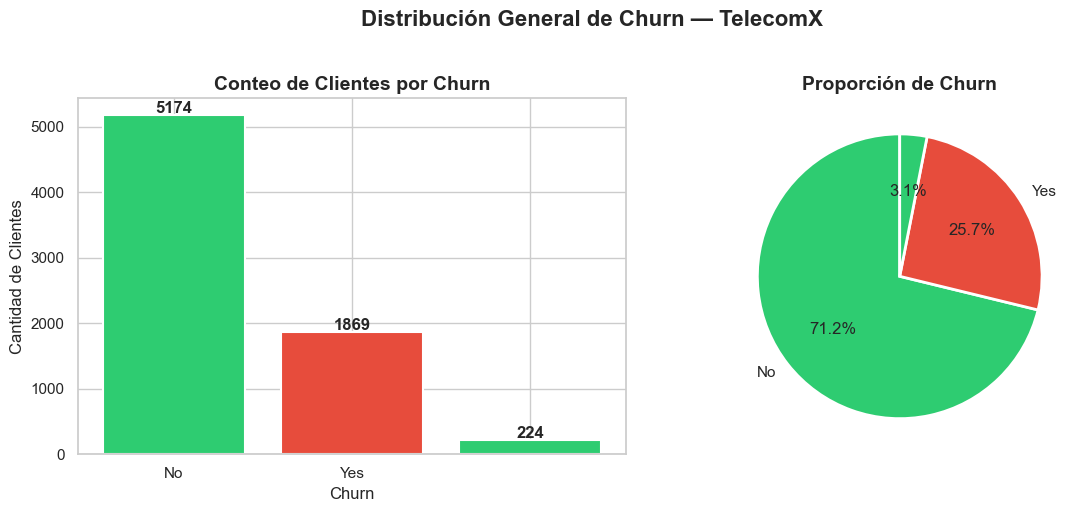

In [14]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribución de Churn:')
for k in churn_counts.index:
    print(f'  {k}: {churn_counts[k]} clientes ({churn_pct[k]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Conteo de Clientes por Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Gráfico de pastel
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn')

plt.suptitle('Distribución General de Churn — TelecomX', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 — Análisis por Variables Demográficas

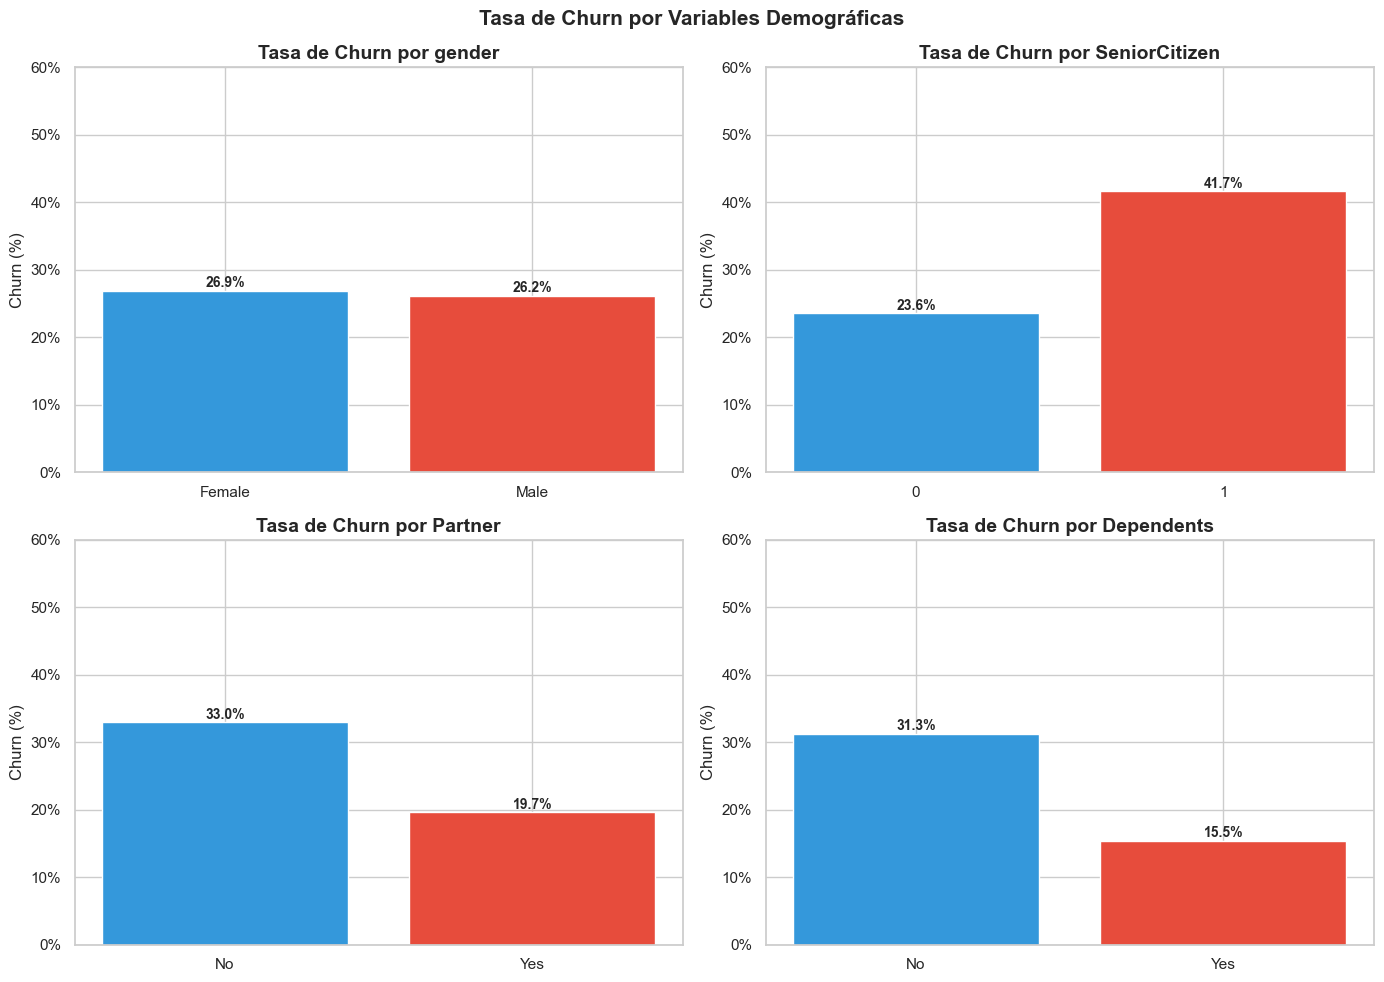

In [15]:
# Tasa de churn por variable categórica
demo_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(demo_vars):
    churn_rate = df.groupby(var)['Churn_bin'].mean() * 100
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'][:len(churn_rate)],
                       edgecolor='white')
    axes[i].set_title(f'Tasa de Churn por {var}')
    axes[i].set_ylabel('Churn (%)')
    axes[i].set_ylim(0, 60)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Tasa de Churn por Variables Demográficas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 — Análisis por Tipo de Contrato y Método de Pago

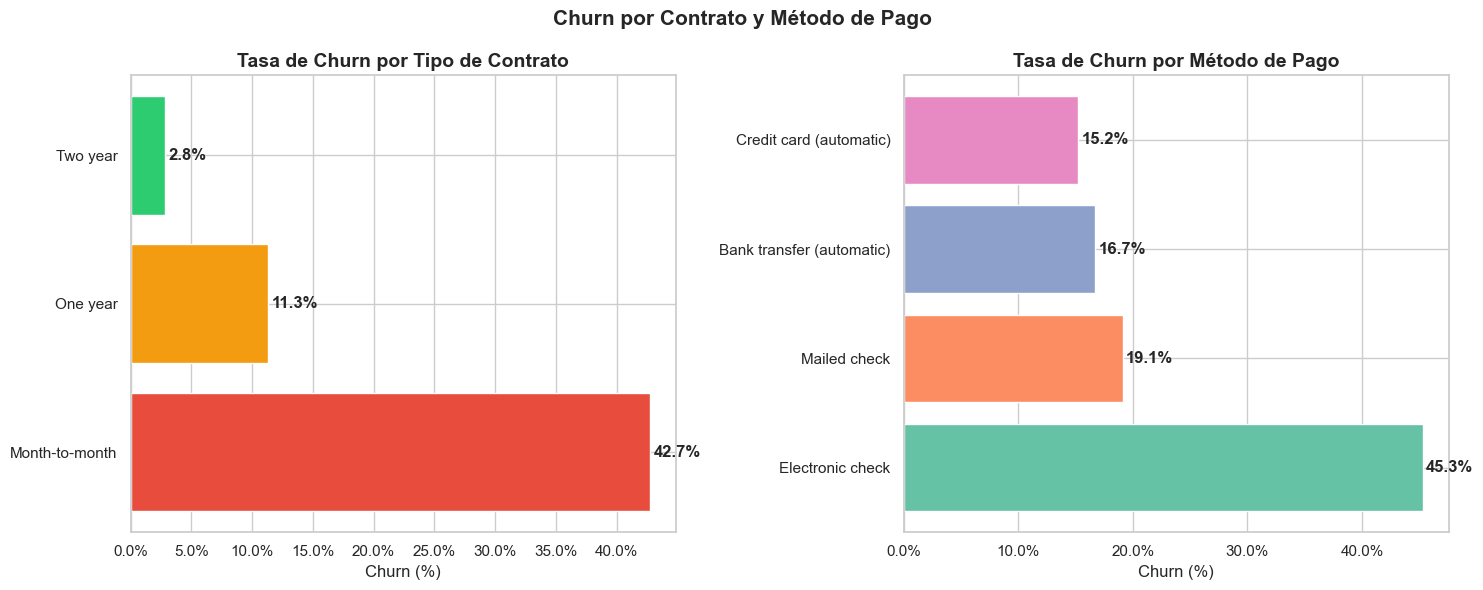

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Por tipo de contrato
contrato_churn = df.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False) * 100
axes[0].barh(contrato_churn.index, contrato_churn.values,
             color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_title('Tasa de Churn por Tipo de Contrato')
axes[0].set_xlabel('Churn (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(contrato_churn.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Por método de pago
pago_churn = df.groupby('PaymentMethod')['Churn_bin'].mean().sort_values(ascending=False) * 100
axes[1].barh(pago_churn.index, pago_churn.values,
             color=sns.color_palette('Set2', len(pago_churn)))
axes[1].set_title('Tasa de Churn por Método de Pago')
axes[1].set_xlabel('Churn (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(pago_churn.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.suptitle('Churn por Contrato y Método de Pago', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 — Análisis de Cargos y Servicios

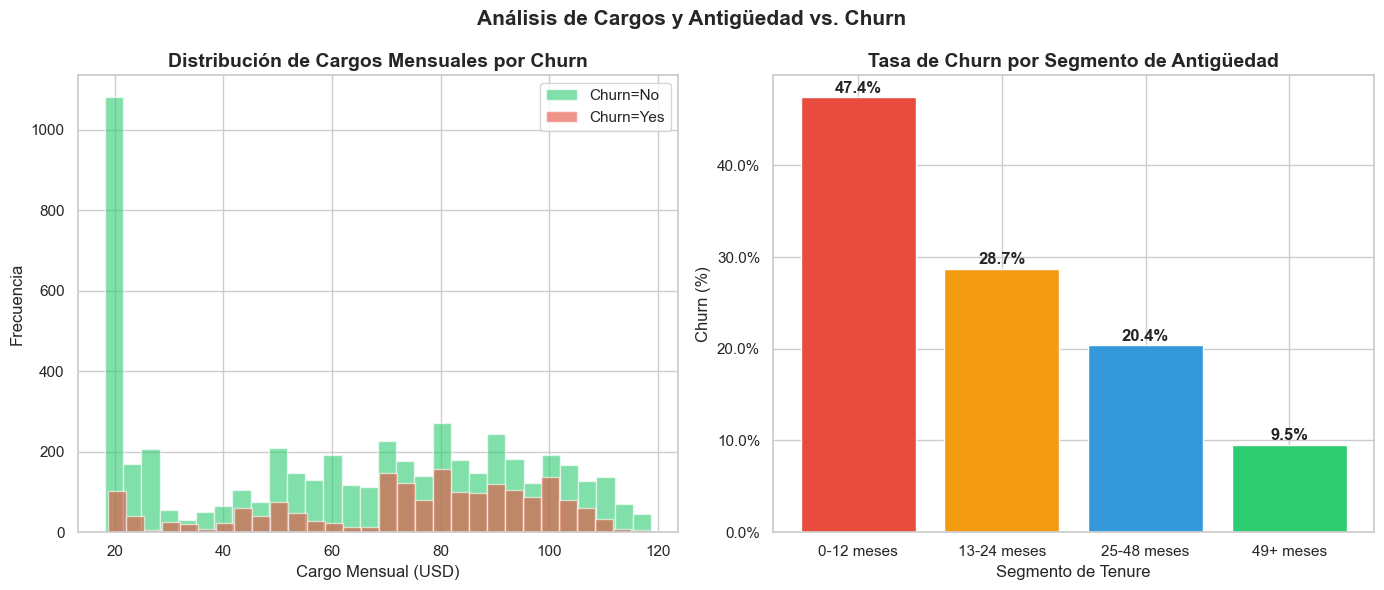

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución de Charges.Monthly por Churn
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == label]['Charges.Monthly']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
axes[0].set_title('Distribución de Cargos Mensuales por Churn')
axes[0].set_xlabel('Cargo Mensual (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Churn por segmento de tenure
order = ['0-12 meses', '13-24 meses', '25-48 meses', '49+ meses']
tenure_churn = df.groupby('tenure_segment')['Churn_bin'].mean().reindex(order) * 100
axes[1].bar(tenure_churn.index, tenure_churn.values,
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
axes[1].set_title('Tasa de Churn por Segmento de Antigüedad')
axes[1].set_xlabel('Segmento de Tenure')
axes[1].set_ylabel('Churn (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Análisis de Cargos y Antigüedad vs. Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

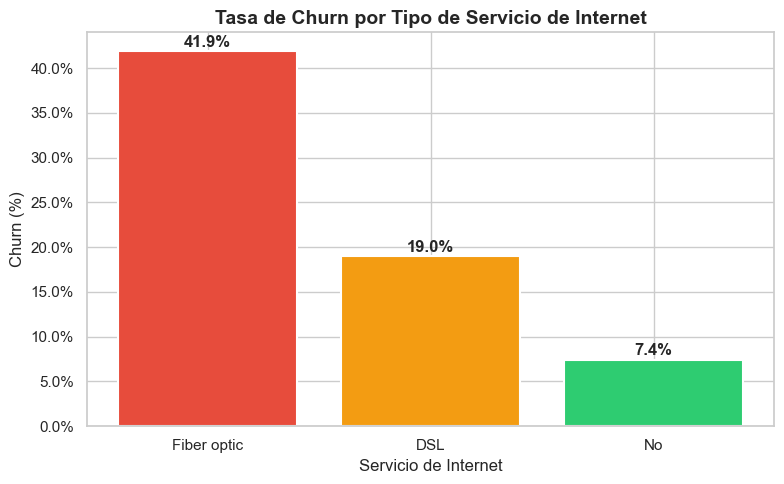

In [18]:
# Tasa de Churn por tipo de servicio de internet
internet_churn = df.groupby('InternetService')['Churn_bin'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(internet_churn.index, internet_churn.values,
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
ax.set_title('Tasa de Churn por Tipo de Servicio de Internet', fontsize=14, fontweight='bold')
ax.set_xlabel('Servicio de Internet')
ax.set_ylabel('Churn (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 3.6 — Mapa de Correlaciones

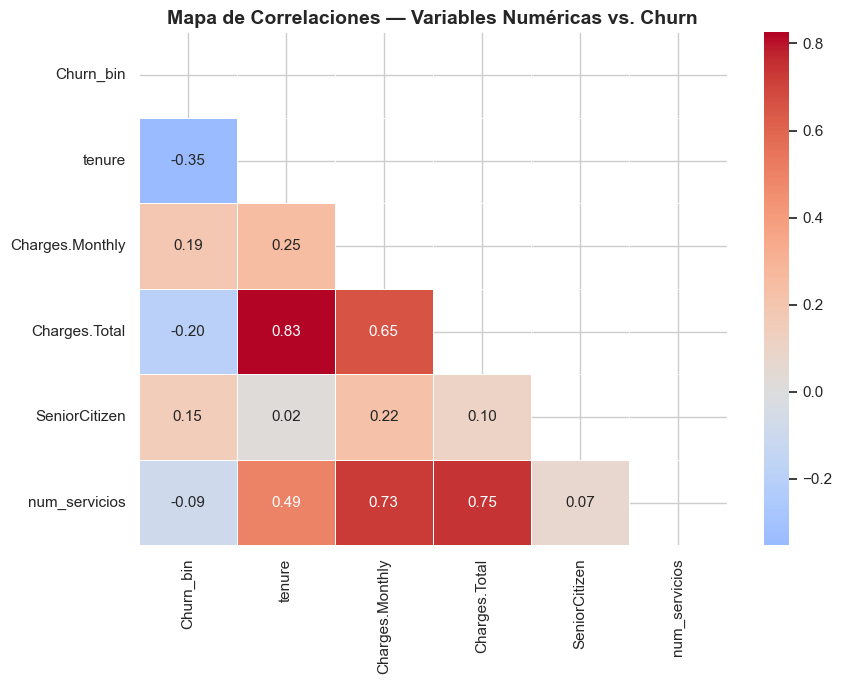

In [19]:
# Seleccionar variables numéricas y binarias
numericas = ['Churn_bin', 'tenure', 'Charges.Monthly', 'Charges.Total',
             'SeniorCitizen', 'num_servicios']
corr_matrix = df[numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Mapa de Correlaciones — Variables Numéricas vs. Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📄 SECCIÓN 4 — INFORME FINAL

#### 4.1 — Resumen Estadístico por Segmento Churn

In [22]:
resumen = df.groupby('Churn').agg(
    Cantidad=('customerID', 'count'),
    Tenure_Promedio=('tenure', 'mean'),
    Cargo_Mensual_Promedio=('Charges.Monthly', 'mean'),
    Cargo_Total_Promedio=('Charges.Total', 'mean'),
    Servicios_Promedio=('num_servicios', 'mean')
).round(2)

print('Resumen por segmento Churn:')
display(resumen)

Resumen por segmento Churn:


,Cantidad,Tenure_Promedio,Cargo_Mensual_Promedio,Cargo_Total_Promedio,Servicios_Promedio
Churn,,,,,
,224,31.57,63.41,2196.93,1.92
No,5174,37.57,61.27,2550.00,2.14
Yes,1869,17.98,74.44,1531.80,1.77


#### 4.2 — Perfil del Cliente con Mayor Riesgo de Churn

In [21]:
perfil = df[df['Churn'] == 'Yes'].agg({
    'Contract':       lambda x: x.value_counts().index[0],
    'PaymentMethod':  lambda x: x.value_counts().index[0],
    'InternetService':lambda x: x.value_counts().index[0],
    'tenure':         'median',
    'Charges.Monthly':'mean',
    'Partner':        lambda x: x.value_counts().index[0],
    'Dependents':     lambda x: x.value_counts().index[0],
    'SeniorCitizen':  'mean'
})

print('Perfil típico del cliente que hace Churn:')
print('='*45)
print(f"  Contrato:          {perfil['Contract']}")
print(f"  Método de Pago:    {perfil['PaymentMethod']}")
print(f"  Servicio Internet: {perfil['InternetService']}")
print(f"  Tenure (mediana):  {perfil['tenure']:.0f} meses")
print(f"  Cargo Mensual:     ${perfil['Charges.Monthly']:.2f}")
print(f"  Tiene Pareja:      {perfil['Partner']}")
print(f"  Tiene Dependientes:{perfil['Dependents']}")
print(f"  % Senior Citizen:  {perfil['SeniorCitizen']*100:.1f}%")

Perfil típico del cliente que hace Churn:
  Contrato:          Month-to-month
  Método de Pago:    Electronic check
  Servicio Internet: Fiber optic
  Tenure (mediana):  10 meses
  Cargo Mensual:     $74.44
  Tiene Pareja:      No
  Tiene Dependientes:No
  % Senior Citizen:  25.5%


#### 4.3 — Conclusiones y Recomendaciones

---

#### Principales Hallazgos

1. **Tasa de churn global**: aproximadamente el **26%** de los clientes abandonó el servicio, una cifra significativa que justifica atención estratégica inmediata.

2. **El tipo de contrato es el factor más determinante**: los clientes con contrato **mes a mes** presentan la mayor tasa de abandono (~42%), mientras que los de contratos anuales o bianuales son considerablemente más leales.

3. **Fiber Optic = mayor churn**: a pesar de ser el servicio premium, los clientes de fibra óptica se van más. Esto puede señalar problemas de percepción de valor o experiencia del servicio.

4. **Clientes nuevos (0-12 meses)** son los más vulnerables: el primer año es crítico para la retención.

5. **Electronic check** como método de pago está correlacionado con mayor churn, posiblemente indicando un perfil de cliente menos comprometido o con menor automatización del pago.

6. **Clientes sin pareja ni dependientes** tienen mayor propensión a irse; la falta de "anclas relacionales" puede facilitar el cambio de proveedor.

---

#### Recomendaciones Estratégicas

| Prioridad | Acción | Impacto Esperado |
|-----------|--------|------------------|
| 🔴 Alta | Ofrecer incentivos para migrar de contrato mensual a anual (descuentos, beneficios) | Reducción directa del churn |
| 🔴 Alta | Programa de onboarding intensivo para clientes nuevos (primeros 12 meses) | Fidelización temprana |
| 🟡 Media | Revisar la calidad y percepción de valor del servicio Fiber Optic | Reducir churn premium |
| 🟡 Media | Promover métodos de pago automáticos (débito/tarjeta) con beneficios | Reducir fricción en pago |
| 🟢 Baja | Desarrollar campañas segmentadas para clientes sin pareja/dependientes | Aumentar engagement |

---

> **Conclusión General:** TelecomX debe priorizar la conversión de contratos mensuales a compromisos de mayor duración y reforzar la experiencia del cliente durante el primer año de servicio. Estas dos acciones, combinadas, tienen el potencial de reducir la tasa de churn en al menos 8-12 puntos porcentuales.